# Anemia Classification with EDA

<p style="text-align:center;"><img src= "https://media.istockphoto.com/illustrations/anemia-diagram-illustration-id506289056" alt ="Anemia" style='width: 500px;'></p>

### **What is Anemia?**
Anemia is a condition in which you lack enough healthy red blood cells to carry adequate oxygen to your body's tissues. Having anemia, also referred to as low hemoglobin, can make you feel tired and weak.

There are many forms of anemia, each with its own cause. Anemia can be temporary or long term and can range from mild to severe. In most cases, anemia has more than one cause. See your doctor if you suspect that you have anemia. It can be a warning sign of serious illness. 


# 1. Exploratory Data Analysis(EDA)

#### Importing the necessary libraries

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn import preprocessing

#### Find the file path of data and load it

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
data=pd.read_csv('/kaggle/input/anemia-dataset/anemia.csv')

#### Let's visualize the data and see which features could be used the predict the result label

In [ ]:
data.head()

In [ ]:
data.info()

In [ ]:
data.isnull().sum() #checking for total null values

#### Let's see how many people have anemia in the dataset. It will give an idea whether the data is balanced or imbalanced

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Result'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('had anemia')
ax[0].set_ylabel('')
sns.countplot('Result',data=data,ax=ax[1])
ax[1].set_title('had anemia')
plt.show()

### Categorical Feature: Gender

In [ ]:
data.groupby(['Gender','Result'])['Result'].count()

In [ ]:
f,ax=plt.subplots(1,2,figsize=(10,7))
data[['Gender','Result']].groupby(['Gender']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Having Anemia vs Gender')
sns.countplot('Gender',hue='Result',data=data,ax=ax[1])
ax[1].set_title('Gender:Having Anemia vs Not Having Anemia')
plt.show()

### Continious Feature: Hemoglobin

In [ ]:
# See the min, max, mean values
print('The highest hemoglobin was of:',data['Hemoglobin'].max())
print('The lowest hemoglobin was of:',data['Hemoglobin'].min())
print('The average hemoglobin in the data:',data['Hemoglobin'].mean())

<div class="alert alert-block alert-info"> 📌 Lower than normal hemoglobin levels indicate anemia. The normal hemoglobin range is generally defined as 13.2 to 16.6 grams (g) of hemoglobin per deciliter (dL) of blood for men and 11.6 to 15 g/dL for women.</div>

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
data_len=data[data['Result']==1]['Hemoglobin'].value_counts()
ax1.hist(data_len,color='red')
ax1.set_title('Having anemia')
data_len=data[data['Result']==0]['Hemoglobin'].value_counts()
ax2.hist(data_len,color='green')
ax2.set_title('NOT Having anemia')
fig.suptitle('Hemoglobin Levels')
plt.show()

### Continious Feature: MCH (Mean Corpuscular Hemoglobin)

In [ ]:
# See the min, max, mean values
print('The highest MCH was of:',data['MCH'].max())
print('The lowest MCH was of:',data['MCH'].min())
print('The average MCH in the data:',data['MCH'].mean())

<div class="alert alert-block alert-info"> 📌 MCH stands for “mean corpuscular hemoglobin.” An MCH value refers to the average quantity of hemoglobin present in a single red blood cell. Hemoglobin is the protein in your red blood cells that transports oxygen to the tissues of your body</div>

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
data_len=data[data['Result']==1]['MCH'].value_counts()
ax1.hist(data_len,color='red')
ax1.set_title('Having anemia')
data_len=data[data['Result']==0]['MCH'].value_counts()
ax2.hist(data_len,color='green')
ax2.set_title('NOT Having anemia')
fig.suptitle('MCH Levels')
plt.show()

### Continious Feature: MCHC (Mean Corpuscular Hemoglobin Concentration)

In [ ]:
# See the min, max, mean values
print('The highest MCHC was of:',data['MCHC'].max())
print('The lowest MCHC was of:',data['MCHC'].min())
print('The average MCHC in the data:',data['MCHC'].mean())

<div class="alert alert-block alert-info"> 📌 A similar measure to MCH is something doctors call "mean corpuscular hemoglobin concentration" (MCHC). MCHC checks the average amount of hemoglobin in a group of red blood cells.</div>

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
data_len=data[data['Result']==1]['MCHC'].value_counts()
ax1.hist(data_len,color='red')
ax1.set_title('Having anemia')
data_len=data[data['Result']==0]['MCHC'].value_counts()
ax2.hist(data_len,color='green')
ax2.set_title('NOT Having anemia')
fig.suptitle('MCHC Levels')
plt.show()

### Continious Feature: MCV (Mean Corpuscular Volume)

In [ ]:
# See the min, max, mean values
print('The highest MCV was of:',data['MCV'].max())
print('The lowest MCV was of:',data['MCV'].min())
print('The average MCV in the data:',data['MCV'].mean())

<div class="alert alert-block alert-info"> 📌 Mean corpuscular volume (MCV) is a laboratory value that measures the average size and volume of a red blood cell. It has utility in helping determine the etiology of anemia — calculation of the value is by multiplying the percent hematocrit by ten divided by the erythrocyte count.</div>

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
data_len=data[data['Result']==1]['MCV'].value_counts()
ax1.hist(data_len,color='red')
ax1.set_title('Having anemia')
data_len=data[data['Result']==0]['MCV'].value_counts()
ax2.hist(data_len,color='green')
ax2.set_title('NOT Having anemia')
fig.suptitle('MCV Levels')
plt.show()

# 2. Feature Engineering and Data Cleaning

We need to convert the continous values into categorical values by either Binning or Normalisation. Binning and normalisation both will be used in this section i.e group a range of ages into a single bin or assign them a single value.

In [ ]:
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2) #data.corr()-->correlation matrix
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

In [ ]:
from sklearn import preprocessing
import pandas as pd

d = preprocessing.normalize(data.iloc[:,1:5], axis=0)
scaled_df = pd.DataFrame(d, columns=["Hemoglobin", "MCH", "MCHC", "MCV"])
scaled_df.head()

# 3. Predictive Modelling

In [ ]:
#importing all the required ML packages
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn import svm #support vector Machine
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.model_selection import train_test_split #training and testing data split
from sklearn import metrics #accuracy measure
from sklearn.metrics import confusion_matrix #for confusion matrix

#### Splitting the data into test and train sets

In [ ]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['Result'])
train_X=train[train.columns[:-1]]
train_Y=train[train.columns[-1:]]
test_X=test[test.columns[:-1]]
test_Y=test[test.columns[-1:]]
X=data[data.columns[:-1]]
Y=data['Result']
len(train_X), len(train_Y), len(test_X), len(test_Y)

#### Radial Support Vector Machines(rbf-SVM)

In [ ]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X,train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ',metrics.accuracy_score(prediction1,test_Y))

#### Linear Support Vector Machine(linear-SVM)

In [ ]:
model=svm.SVC(kernel='linear',C=0.1,gamma=0.1)
model.fit(train_X,train_Y)
prediction2=model.predict(test_X)
print('Accuracy for linear SVM is',metrics.accuracy_score(prediction2,test_Y))

#### Logistic Regression

In [ ]:
model = LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction3,test_Y))

#### Decision Tree

In [ ]:
model=DecisionTreeClassifier()
model.fit(train_X,train_Y)
prediction4=model.predict(test_X)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction4,test_Y))

#### K-Nearest Neighbours(KNN)

In [ ]:
model=KNeighborsClassifier() 
model.fit(train_X,train_Y)
prediction5=model.predict(test_X)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction5,test_Y))

#### Gaussian Naive Bayes

In [ ]:
model=GaussianNB()
model.fit(train_X,train_Y)
prediction6=model.predict(test_X)
print('The accuracy of the NaiveBayes is',metrics.accuracy_score(prediction6,test_Y))

#### Random Forests

In [ ]:
model=RandomForestClassifier(n_estimators=100)
model.fit(train_X,train_Y)
prediction7=model.predict(test_X)
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction7,test_Y))

### Cross Validation

In [ ]:
from sklearn.model_selection import KFold #for K-fold cross validation
from sklearn.model_selection import cross_val_score #score evaluation
from sklearn.model_selection import cross_val_predict #prediction
kfold = KFold(n_splits=10) # k=10, split the data into 10 equal parts
cv_mean=[]
accuracy=[]
std=[]
classifiers=['Linear Svm','Radial Svm','Logistic Regression','KNN','Decision Tree','Naive Bayes','Random Forest']
models=[svm.SVC(kernel='linear'),svm.SVC(kernel='rbf'),LogisticRegression(),KNeighborsClassifier(n_neighbors=9),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(n_estimators=100)]
for i in models:
    model = i
    cv_result = cross_val_score(model,X,Y, cv = kfold,scoring = "accuracy")
    cv_result=cv_result
    cv_mean.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)
new_models_dataframe2=pd.DataFrame({'CV Mean':cv_mean,'Std':std},index=classifiers)       
new_models_dataframe2

In [ ]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig=plt.gcf()
fig.set_size_inches(8,5)
plt.show()

In [ ]:
f,ax=plt.subplots(3,3,figsize=(12,10))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,0],annot=True,fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')
y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,1],annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')
y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=5),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,2],annot=True,fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')
y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,0],annot=True,fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')
y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,1],annot=True,fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')
y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,2],annot=True,fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')
y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[2,0],annot=True,fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

### Ensembling

In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble_lin_rbf=VotingClassifier(estimators=[('KNN',KNeighborsClassifier(n_neighbors=5)),
                                              ('RBF',svm.SVC(probability=True,kernel='rbf',C=0.5,gamma=0.1)),
                                              ('RFor',RandomForestClassifier(n_estimators=500,random_state=0)),
                                              ('LR',LogisticRegression(C=0.05)),
                                              ('DT',DecisionTreeClassifier(random_state=0)),
                                              ('NB',GaussianNB()),
                                              ('svm',svm.SVC(kernel='linear',probability=True))
                                             ], 
                       voting='soft').fit(train_X,train_Y)
print('The accuracy for ensembled model is:',ensemble_lin_rbf.score(test_X,test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y, cv = 10,scoring = "accuracy")
print('The cross validated score is :',cross.mean())

#### Boosting

##### AdaBoostClassifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.1)
result=cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:',result.mean())

##### GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
grad=GradientBoostingClassifier(n_estimators=500,random_state=0,learning_rate=0.1)
result=cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:',result.mean())

##### XGBoost

In [ ]:
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

#### **We reached 100% accuracy in the prediction of anemia. This notebook provides information not only about the Machine Learning also about a sickness that is Anemia. If you like it, please upvote the notebook.** 

##### Resources about the Anemia : 
* https://www.mayoclinic.org/diseases-conditions/anemia/symptoms-causes/syc-20351360
* https://www.mayoclinic.org/diseases-conditions/iron-deficiency-anemia/diagnosis-treatment/drc-20355040#:~:text=Hemoglobin.,15%20g%2FdL%20for%20women.
* https://www.webmd.com/a-to-z-guides/what-are-mch-levels#:~:text=MCHC%20checks%20the%20average%20amount,as%20well%20as%20they%20should.
* https://www.healthline.com/health/mch
* https://www.ncbi.nlm.nih.gov/books/NBK545275/#:~:text=Mean%20corpuscular%20volume%20(MCV)%20is%20a%20laboratory%20value%20that%20measures,divided%20by%20the%20erythrocyte%20count.

<p style="text-align:center;">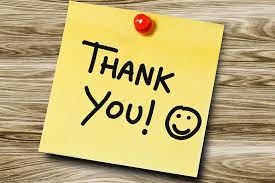</p>